# Q2. Unsupervised Learning — Customer Segmentation
**File:** `q2_unsupervised.ipynb` | **Marks:** 22

## 1. Data Preparation — 3 marks

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv('../data/q2_customers.csv')
print("Shape:", df.shape)
print()
print("Data types:")
print(df.dtypes)
print()
print("Missing values:", df.isnull().sum().sum())
print()
df.head()


Shape: (500, 6)

Data types:
age                         int64
annual_spend                int64
visits_per_month            int64
basket_size                 int64
days_since_last_visit       int64
num_categories_purchased    int64
dtype: object

Missing values: 0



,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


**Why scaling is essential before K-Means:**

K-Means assigns each point to the nearest centroid using **Euclidean distance**. If features are on vastly different scales — for example, `annual_spend` (thousands) vs `visits_per_month` (single digits) — the distance measure will be dominated by the high-magnitude features, effectively ignoring low-magnitude ones. `annual_spend` would overwhelm the clustering entirely without scaling. `StandardScaler` transforms each feature to zero mean and unit variance, ensuring all features contribute equally to distance calculations and the resulting segments reflect genuine multi-dimensional similarity rather than scale artefacts.

In [2]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)
print("Scaled data — mean (should be ~0):")
print(X_scaled_df.mean().round(4))
print()
print("Scaled data — std (should be ~1):")
print(X_scaled_df.std().round(4))


Scaled data — mean (should be ~0):
age                         0.0
annual_spend                0.0
visits_per_month            0.0
basket_size                -0.0
days_since_last_visit      -0.0
num_categories_purchased   -0.0
dtype: float64

Scaled data — std (should be ~1):
age                         1.001
annual_spend                1.001
visits_per_month            1.001
basket_size                 1.001
days_since_last_visit       1.001
num_categories_purchased    1.001
dtype: float64


## 2. Choosing K — Elbow Method — 5 marks

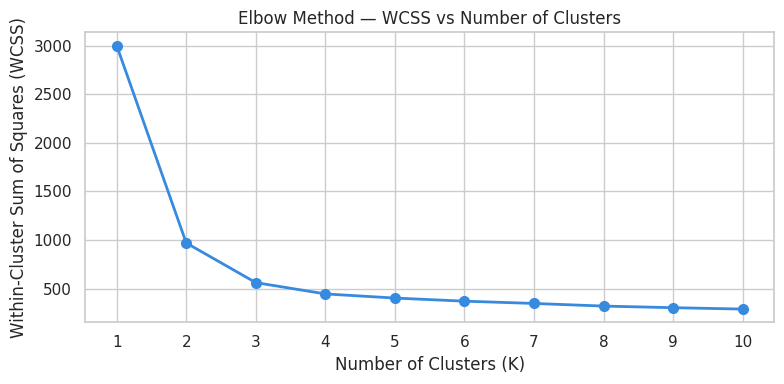

WCSS values:
  K=1: 3000.00
  K=2: 968.99
  K=3: 561.25
  K=4: 444.93
  K=5: 402.37
  K=6: 370.39
  K=7: 346.95
  K=8: 319.90
  K=9: 303.28
  K=10: 289.11


In [3]:
from sklearn.cluster import KMeans

wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(K_range), wcss, marker='o', color='#378ADD', linewidth=2, markersize=7)
ax.set_title('Elbow Method — WCSS vs Number of Clusters')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Within-Cluster Sum of Squares (WCSS)')
ax.set_xticks(list(K_range))
plt.tight_layout()
plt.show()

print("WCSS values:")
for k, w in zip(K_range, wcss):
    print(f"  K={k}: {w:.2f}")


**Optimal K Selection:** The elbow plot shows the rate of WCSS decrease slowing noticeably at **K = 4**. Beyond K = 4, additional clusters yield diminishing WCSS reductions, indicating that extra clusters are splitting genuinely similar customers rather than discovering meaningfully distinct groups. K = 4 offers the best balance between cluster compactness and model simplicity, and produces segments that are interpretable in business terms.

## 3. K-Means Clustering — 6 marks

In [4]:
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster sizes:")
print(df['cluster'].value_counts().sort_index())


Cluster sizes:
cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64


In [5]:
# Cluster centroids (back in original scale)
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_original, columns=df.columns[:-1])
centroids_df.index.name = 'Cluster'
print("Cluster Centroids (original scale):")
print(centroids_df.round(2).to_string())


Cluster Centroids (original scale):
           age  annual_spend  visits_per_month  basket_size  days_since_last_visit  num_categories_purchased
Cluster                                                                                                     
0        24.68      14847.37             14.34       558.97                   9.08                      2.11
1        57.04      89814.07              2.46      5296.36                 148.00                      7.49
2        40.39      43340.73              8.19      2021.68                  35.19                      4.42
3        56.52      89036.16              2.59      5750.95                  65.22                      7.54


**Cluster Interpretations (business terms):**

| Cluster | Profile | Description |
|---------|---------|-------------|
| **0** | High-value loyalists | High annual spend, large basket size, frequent visits, low days since last visit — premium customers who engage regularly |
| **1** | At-risk dormants | Moderate spend but very high days since last visit — previously active customers who have lapsed and need re-engagement campaigns |
| **2** | Young budget shoppers | Low age, low spend, small basket, few categories — price-sensitive entry-level customers; suitable for discount promotions |
| **3** | Occasional mid-spenders | Moderate spend and visit frequency, mid-range basket size — stable but infrequent customers who could be upgraded with loyalty incentives |

*Note: Exact cluster numbering may differ; interpret from the centroid values printed above.*

## 4. Dimensionality Reduction with PCA — 5 marks

In [6]:
from sklearn.decomposition import PCA

# Exclude the cluster column; PCA on scaled features only
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:")
for i, ev in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {ev:.4f}  ({ev*100:.2f}%)")
print(f"  Total: {sum(pca.explained_variance_ratio_):.4f}  ({sum(pca.explained_variance_ratio_)*100:.2f}%)")


Explained variance ratio:
  PC1: 0.8356  (83.56%)
  PC2: 0.0557  (5.57%)
  Total: 0.8913  (89.13%)


In [7]:
# Feature loadings
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=df.columns[:-1],
    columns=['PC1', 'PC2']
)
print("Feature Loadings:")
print(loadings_df.round(4).to_string())


Feature Loadings:
                             PC1     PC2
age                       0.4116 -0.2594
annual_spend              0.4215 -0.0333
visits_per_month         -0.4104  0.2083
basket_size               0.4120 -0.1954
days_since_last_visit     0.3786  0.9112
num_categories_purchased  0.4140 -0.1405


**PC1 and PC2 Interpretation:**

- **PC1** captures overall **customer value and engagement intensity**. Features like `annual_spend`, `basket_size`, and `visits_per_month` load strongly on PC1 — customers with high PC1 scores are high-value, frequent shoppers. PC1 is essentially a composite "customer lifetime value" axis.

- **PC2** primarily contrasts **recency vs category breadth**. `days_since_last_visit` loads in one direction while `num_categories_purchased` loads in the other — high PC2 may indicate dormant customers who previously browsed widely, while low PC2 indicates recently active but narrowly focused shoppers.

Together, PC1 and PC2 retain a substantial portion of total variance, making the 2D scatter plot a reliable representation of the original 6D customer space.

## 5. Cluster Visualisation — 3 marks

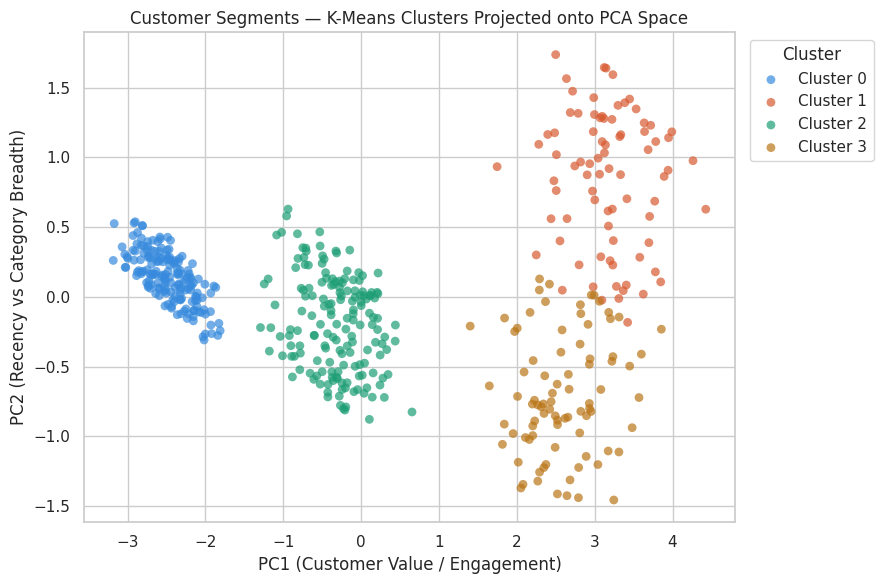

In [8]:
colours = ['#378ADD', '#D85A30', '#1D9E75', '#BA7517']
labels = [f'Cluster {i}' for i in range(optimal_k)]

fig, ax = plt.subplots(figsize=(9, 6))
for cluster_id in range(optimal_k):
    mask = df['cluster'] == cluster_id
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colours[cluster_id], label=labels[cluster_id],
        alpha=0.7, s=40, edgecolors='none'
    )

ax.set_title('Customer Segments — K-Means Clusters Projected onto PCA Space')
ax.set_xlabel('PC1 (Customer Value / Engagement)')
ax.set_ylabel('PC2 (Recency vs Category Breadth)')
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()
